# III. Prescriptive / Multivariate Analysis

## Hospitalized Patients with Heart Failure

### Objective

The Descriptive Analysis established the baseline characteristics, clinical severity, comorbidity burden, laboratory patterns, treatment patterns, hospitalization outcomes, and readmission/mortality rates in the cohort.

The Prescriptive / Multivariate Analysis builds on those findings by investigating relationships between multiple clinical, demographic, treatment, and outcome variables.

The objective is to identify:

- factors associated with clinical severity and outcomes,
- combinations of factors that identify different patient profiles,
- relationships between clinical condition and hospitalization/resource use,
- factors that provide information beyond individual severity measures,
- and evidence-supported candidate features for the Predictive Analysis.

Rather than analyzing variables independently, this stage focuses on clinically meaningful relationships and combinations of variables.

### Analytical Flow

Descriptive Findings
        ↓
Identify Important Patterns
        ↓
Formulate Analytical Questions
        ↓
Test Relationships and Interactions
        ↓
Identify Meaningful Patient Profiles
        ↓
Evaluate Incremental Information
        ↓
Select Evidence-Supported Candidate Predictors
        ↓
Predictive Analysis

## 1. Import Libraries
The Prescriptive Analysis requires statistical comparisons, association testing, subgroup analysis, and visualization.
We will use a focused set of Python libraries rather than importing unnecessary packages.


In [6]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Cleaned Master Patient Dataset
The data-cleaning stage has already produced the patient-level analytical dataset.

The Prescriptive Analysis should use the cleaned master dataset so that all questions are based on the same patient population and the same previously validated definitions.

#### What will we do?
Load the finalized `patient_master.csv` created during the Data Cleaning stage.

A single patient-level dataset containing the clinical, demographic, hospitalization, outcome, and treatment information required for the Prescriptive Analysis.

In [3]:
from pathlib import Path

# Try the team's original path first, then common locations near this notebook.
DATA_PATH = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)
candidates = [DATA_PATH / "cleaned_data" / "patient_master.csv"]
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates += [base / "cleaned_data" / "patient_master.csv",
                   base / "patient_master.csv"]

MASTER_PATH = next((p for p in candidates if p.is_file()), None)
if MASTER_PATH is None:
    raise FileNotFoundError(
        "Could not find patient_master.csv. Run the final cleaning notebook, "
        "then put the CSV in cleaned_data/ beside this notebook."
    )
CLEANED_PATH = MASTER_PATH.parent
df = pd.read_csv(MASTER_PATH)
print("Master dataset loaded:", MASTER_PATH)
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Master dataset loaded: /home/4060d586-5427-4c4d-ab78-dbc3acb0b9c3/cleaned_data/patient_master.csv
Rows: 2,008; columns: 198


## 3. Analytical Dataset Validation

Before beginning multivariate analysis, we need to confirm that the analytical dataset has the expected patient-level structure.
This prevents accidental use of duplicate records, incorrect joins, or unexpected changes to the cleaned dataset.

- Number of patients
- Unique patient identifiers
- Duplicate patient records
- Availability of key variables
- Data types of variables used in Category 3

Confirm that the Prescriptive Analysis is based on the same 2,008-patient master cohort established during data cleaning.

In [4]:
# Verify patient-level structure and names from the final cleaning notebook.
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())
print("Duplicate patient IDs:", df["inpatient_number"].duplicated().sum())
key_variables = [
    "inpatient_number", "glomerular_filtration_rate", "cci_score",
    "nyha_cardiac_function_classification", "killip_grade",
    "brain_natriuretic_peptide", "dischargeday",
    "re_admission_within_6_months", "death_within_6_months",
    "age_category", "diabetes", "moderate_to_severe_chronic_kidney_disease"
]
available = [name for name in key_variables if name in df.columns]
missing = [name for name in key_variables if name not in df.columns]
print("Available:", available)
print("Missing:", missing)
if missing or df["inpatient_number"].duplicated().any():
    raise ValueError("The master CSV does not match the final cleaned patient dataset.")

Dataset shape: (2008, 198)
Unique patients: 2008
Duplicate patient IDs: 0
Available: ['inpatient_number', 'glomerular_filtration_rate', 'cci_score', 'nyha_cardiac_function_classification', 'killip_grade', 'brain_natriuretic_peptide', 'dischargeday', 're_admission_within_6_months', 'death_within_6_months', 'age_category', 'diabetes', 'moderate_to_severe_chronic_kidney_disease']
Missing: []


### 4. Transition from Descriptive to Prescriptive / Multivariate Analysis

The Descriptive Analysis established several important characteristics of the cohort.

Key observations included:

- A substantial proportion of patients had reduced renal function based on measured GFR.
- The prevalence of the CKD indicator was lower than the proportion with measured GFR <60 mL/min/1.73 m².
- Admission severity was characterized using NYHA and Killip classifications.
- BNP showed a strongly right-skewed distribution and varied across NYHA severity groups.
- Comorbidity burden was present across the cohort, with CKD and diabetes among the more prevalent conditions.
- Six-month readmission occurred considerably more frequently than six-month mortality.
- Length of stay varied across patients, and exploratory analysis showed an association between medication burden and length of stay.

These findings generate questions that cannot be answered by descriptive statistics alone.

The Prescriptive / Multivariate Analysis therefore moves from:

**"What do we observe?"**

to: **"How are these factors related, do they provide additional information when considered together, and which combinations identify meaningful patient profiles?"**

## Section 1 — Renal Function & Admission Severity

### Q1. Does the CKD flag identify the same renal-risk population as measured GFR <60 mL/min/1.73m²?

**Why:** Descriptive analysis flagged a gap between the coded CKD comorbidity indicator and the share of patients with measured GFR<60. The data dictionary defines that exact indicator using the same <60 cutoff, so the two should largely agree — testing whether they actually do determines which one we trust as the primary renal-risk variable for every downstream question in this section.

**What We Expect:** Given the shared cutoff, we expect substantial but not perfect overlap — some disagreement is plausible if the CKD flag reflects a historical diagnosis while GFR reflects current lab values, but a large gap would suggest the flag under-captures current renal risk.

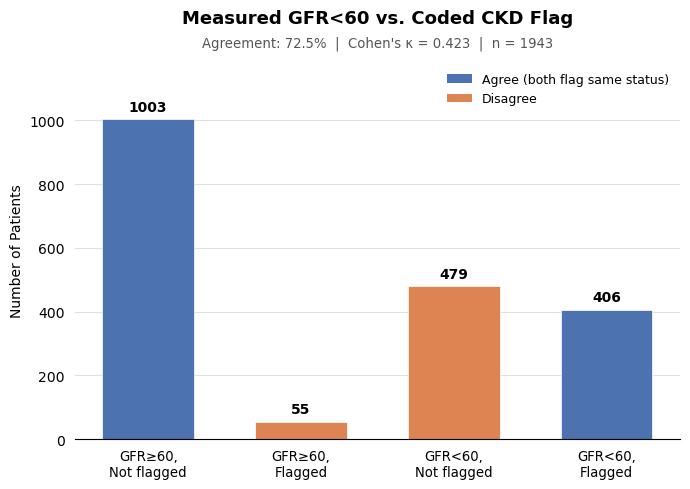

In [7]:
# Recreate the contingency table so the starter Q1 chart works when run from the top.
q1 = df[["glomerular_filtration_rate", "moderate_to_severe_chronic_kidney_disease"]].copy()
q1["glomerular_filtration_rate"] = pd.to_numeric(q1["glomerular_filtration_rate"], errors="coerce")
q1["moderate_to_severe_chronic_kidney_disease"] = pd.to_numeric(
    q1["moderate_to_severe_chronic_kidney_disease"], errors="coerce"
)
q1 = q1.dropna()
q1 = q1[q1["moderate_to_severe_chronic_kidney_disease"].isin([0, 1])]
q1["low_gfr"] = (q1["glomerular_filtration_rate"] < 60).astype(int)
ct = pd.crosstab(q1["low_gfr"], q1["moderate_to_severe_chronic_kidney_disease"])
ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
n = int(ct.to_numpy().sum())
if n == 0:
    raise ValueError("No usable GFR and CKD flag pairs for the Q1 chart.")
po = (ct.loc[0, 0] + ct.loc[1, 1]) / n
row_share = ct.sum(axis=1) / n
col_share = ct.sum(axis=0) / n
pe = row_share.loc[0] * col_share.loc[0] + row_share.loc[1] * col_share.loc[1]
kappa = (po - pe) / (1 - pe) if pe < 1 else float("nan")
display(ct.rename(index={0: "GFR >=60", 1: "GFR <60"},
                  columns={0: "CKD not flagged", 1: "CKD flagged"}))

# Visualization — cleaner version
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["GFR≥60,\nNot flagged", "GFR≥60,\nFlagged", "GFR<60,\nNot flagged", "GFR<60,\nFlagged"]
values = [ct.loc[0,0], ct.loc[0,1], ct.loc[1,0], ct.loc[1,1]]

agree_color = "#4C72B0"     # the two cells where GFR and flag agree
disagree_color = "#DD8452"  # the two cells where they disagree
colors = [agree_color, disagree_color, disagree_color, agree_color]

bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# Labels above bars, with enough headroom so nothing touches the top
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(values) * 1.18)

# Clean up the frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False, bottom=False)

ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("Measured GFR<60 vs. Coded CKD Flag", fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.04, f"Agreement: {po*100:.1f}%  |  Cohen's κ = {kappa:.3f}  |  n = {n}",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#555555")

plt.xticks(fontsize=9.5)

# Legend explaining the color coding
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=agree_color, label="Agree (both flag same status)"),
    Patch(facecolor=disagree_color, label="Disagree"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

**Finding**

885/1,943 (45.55%) have GFR<60; only 461 (23.73%) carry the CKD flag. 479 patients (24.7%) are low-GFR but unflagged; only 55 (2.8%) are flagged with normal GFR. Agreement = 72.5%, but Cohen's κ = 0.423 (moderate, not strong). Chi-square p ≈ 2.46e-97 — significant, but with n=1,943 that reflects sample size, not interchangeability.

**Observation & Implication**

The two measures disagree more than they agree meaningfully (κ=0.423), and the flag under-catches far more than it over-flags. Measured GFR will be used as the primary renal-function variable going forward; the CKD flag stays separate as a comorbidity variable, not a GFR proxy. Sets up Q2 (GFR vs. severity) using the lab value.

**Counter-Argument:** CKD is a chronic diagnosis — some "missed" patients may just have a normal GFR at this admission despite a history of impairment. Doesn't change the choice: current GFR is still the right variable for a cross-sectional analysis.

## Family 3 — Cardiac Biomarker and Renal Function (Questions 11–13)

These analyses use the final `patient_master.csv`. Each question builds a *new*
working table, so it can be run without variables created by another family's
question. Percentages always use patients with a recorded outcome and marker;
a missing biomarker or outcome never counts as a negative result. Results show
associations in these patients, not treatment effects or confirmed clinical risk scores.

In [ ]:
# Step 1: Set exact column names produced by the team's cleaning notebook.
OUTCOME = "re_admission_within_6_months"
DEATH = "death_within_6_months"
BNP = "brain_natriuretic_peptide"
GFR = "glomerular_filtration_rate"
NYHA = "nyha_cardiac_function_classification"
KILLIP = "killip_grade"
CCI = "cci_score"
CKD = "moderate_to_severe_chronic_kidney_disease"

# Step 2: Report counts and observed rates using the correct group denominators.
# Missing outcomes are excluded BEFORE this function is called.
def outcome_rates(frame, groups, outcome):
    result = (frame.groupby(groups, observed=True, dropna=False)[outcome]
              .agg(n="size", events="sum"))
    result["rate_pct"] = (100 * result["events"] / result["n"]).round(1)
    return result

# Step 3: Make a complete-case working copy without changing the master df.
# The cleaning notebook marked a small number of contradictory event records;
# exclude them from analyses of the 6-month readmission label when the flag exists.
def analysis_rows(columns, outcome=OUTCOME):
    cols = list(dict.fromkeys([*columns, outcome]))
    if "event_time_contradiction_flag" in df.columns and outcome == OUTCOME:
        cols.append("event_time_contradiction_flag")
    if "outcome_destination_flag" in df.columns and outcome == DEATH:
        cols.append("outcome_destination_flag")
    work = df[cols].copy()
    if "event_time_contradiction_flag" in work:
        work = work.loc[~work["event_time_contradiction_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="event_time_contradiction_flag")
    if "outcome_destination_flag" in work:
        work = work.loc[~work["outcome_destination_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="outcome_destination_flag")
    for name in cols:
        if name in work and name != "age_category":
            work[name] = pd.to_numeric(work[name], errors="coerce")
    work = work.dropna(subset=list(dict.fromkeys([*columns, outcome])))
    work = work.loc[work[outcome].isin([0, 1])].copy()
    print(f"Usable patients: {len(work):,} of {len(df):,}; {outcome} events: {int(work[outcome].sum()):,}")
    return work

# Step 4: Use the SAME complete cases for each pair of nested logistic models.
# A likelihood-ratio test asks whether the added columns explain outcome
# variation beyond the smaller model; neither model establishes causality.
from scipy.optimize import minimize
def nested_logistic_test(y, base, added):
    y = np.asarray(y, dtype=float)
    base = np.asarray(base, dtype=float).reshape(len(y), -1)
    added = np.asarray(added, dtype=float).reshape(len(y), -1)
    if len(np.unique(y)) < 2:
        print("Both outcome classes are needed; interaction test not estimable.")
        return np.nan, np.nan
    def fit(x):
        x = np.column_stack([np.ones(len(y)), x])
        result = minimize(lambda beta: np.logaddexp(0, x @ beta).sum()
                          - y @ (x @ beta), np.zeros(x.shape[1]), method="L-BFGS-B")
        if not result.success:
            print("Model optimization warning:", result.message)
        return -float(result.fun)
    lr = max(0.0, 2 * (fit(np.column_stack([base, added])) - fit(base)))
    p = stats.chi2.sf(lr, added.shape[1])
    return lr, p

# Severity rule shared by Q13 and Q18. This is an exploratory grouping,
# explicitly defined here so the result cannot be changed after seeing it.
def severe_presentation(frame):
    return (frame[NYHA] >= 4) | (frame[KILLIP] >= 3)

# Anchor subgroup percentages to the overall rates the descriptive
# notebook reported. Subsequent analyses may exclude flagged/missing rows.
for target in [OUTCOME, DEATH]:
    known = pd.to_numeric(df[target], errors="coerce")
    known = known[known.isin([0, 1])]
    print(f"Full-cohort {target}: {int(known.sum())}/{len(known)} = {known.mean():.1%}")
print("Shared helpers ready; master dataframe left unchanged.")

### Q11. Is higher BNP associated with higher six-month readmission?

**Why:** BNP is a heart-failure biomarker. Comparing *readmission rates* across
BNP levels tests whether patients with higher recorded BNP have different
follow-up outcomes. Quartiles are derived from nonmissing BNP values in this
dataset, so they are data groupings rather than clinical cutoffs.

**How:** Remove missing/invalid BNP and missing outcomes; report group size,
readmissions, and within-group rates. Use a chi-square comparison and a
patient-level rank trend as supporting evidence. Also print the BNP boundaries.

In [ ]:
# Step 1: Keep patients with nonmissing BNP and a known binary outcome.
q11 = analysis_rows([BNP])
q11 = q11.loc[q11[BNP] >= 0].copy()
print("Nonnegative BNP measurements:", len(q11))

# Step 2: Rank BNP, then make four roughly equal-sized groups. Ranking
# avoids qcut's duplicate-edge error if several patients have the same BNP.
q11["BNP_quartile"] = pd.qcut(q11[BNP].rank(method="first"), 4,
                              labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
print("BNP by group (min / median / max):")
display(q11.groupby("BNP_quartile", observed=True)[BNP].agg(["min", "median", "max"]))
q11_rates = outcome_rates(q11, "BNP_quartile", OUTCOME)
display(q11_rates)

# Step 3: Compare observed rates and test whether their distribution differs.
cont = pd.crosstab(q11["BNP_quartile"], q11[OUTCOME])
chi2, p, _, expected = chi2_contingency(cont)
rank_r, trend_p = stats.spearmanr(q11["BNP_quartile"].cat.codes, q11[OUTCOME])
print(f"Chi-square p={p:.4g}; rank association r={rank_r:.3f}, p={trend_p:.4g}")
if (expected < 5).any():
    print("Some expected cell counts are below 5; interpret chi-square cautiously.")

# Step 4: Plot percentages AND show the patient counts on each bar.
ax = q11_rates["rate_pct"].plot.bar(figsize=(8, 4), color="#4169a2", rot=0)
ax.set(ylabel="Six-month readmission (%)", xlabel="BNP group",
       title="Six-month readmission across BNP quartiles")
for bar, count in zip(ax.patches, q11_rates["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, q11_rates["rate_pct"].max() * 1.22))
plt.tight_layout(); plt.show()
print("Interpretation: compare Q4 with Q1 using the displayed rates and group sizes;")
print("a p-value or rising pattern alone does not show BNP causes readmission.")

### Q12. Does BNP add information about six-month readmission beyond NYHA and Killip?

**Why:** BNP could reflect information already captured by severity grades.
Test whether adding it to the two severity measures improves separation of
readmitted versus non-readmitted patients *on the same complete-case sample*.

**How:** Compare severity-only and severity-plus-BNP logistic models with
five-fold cross-validated ROC AUC. The likelihood-ratio test offers a separate
measure of association after accounting for NYHA and Killip. This is exploratory
analysis, not a validated clinical prediction model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Same complete patients and outcomes for BOTH model comparisons.
q12 = analysis_rows([NYHA, KILLIP, BNP])
q12 = q12.loc[q12[BNP] >= 0].copy()
q12["log_BNP"] = np.log1p(q12[BNP])  # Compress the right-skewed BNP distribution.
baseline = q12[[NYHA, KILLIP]].to_numpy()
expanded = q12[[NYHA, KILLIP, "log_BNP"]].to_numpy()
y12 = q12[OUTCOME].astype(int).to_numpy()

# Step 2: Split data into the same stratified folds for both models.
folds = min(5, np.bincount(y12).min())
if folds < 2:
    raise ValueError("Not enough outcomes in both classes for Q12 validation.")
cv12 = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
results12 = {}
for name, x in [("NYHA + Killip", baseline), ("NYHA + Killip + BNP", expanded)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities = cross_val_predict(model, x, y12, cv=cv12, method="predict_proba")[:, 1]
    results12[name] = [roc_auc_score(y12, probabilities),
                       brier_score_loss(y12, probabilities)]
comparison12 = pd.DataFrame(results12, index=["CV ROC AUC (higher better)",
                                             "CV Brier score (lower better)"]).T
display(comparison12.round(3))

# Step 3: Test whether BNP is associated with the outcome after accounting
# for the two severity grades on these same patients.
lr12, p12 = nested_logistic_test(y12, baseline, q12[["log_BNP"]])
print(f"BNP added to NYHA + Killip: likelihood-ratio statistic={lr12:.2f}, p={p12:.4g}")
print("Interpretation: compare BOTH AUC and Brier scores. A small/negative")
print("change in held-out performance would not support a useful added signal.")

### Q13. Does the combination of admission severity, BNP and renal function identify a different readmission subgroup?

**Why:** These measures represent different clinical domains. We examine whether
patients with none, one, two, or all three recorded signals show different
observed outcomes, while checking the number of patients in every subgroup.

**Group rules:** severe presentation = NYHA 4 **or** Killip 3–4;
higher BNP = at or above the *complete-case cohort median*; low GFR = <60.
These are exploratory categories, not clinical recommendations.

In [ ]:
# Step 1: Restrict to patients who have all three markers AND outcome recorded.
q13 = analysis_rows([NYHA, KILLIP, BNP, GFR])
q13 = q13.loc[(q13[BNP] >= 0) & (q13[GFR] > 0)].copy()
median_bnp13 = q13[BNP].median()
q13["severe"] = severe_presentation(q13).astype(int)
q13["high_BNP"] = (q13[BNP] >= median_bnp13).astype(int)
q13["low_GFR"] = (q13[GFR] < 60).astype(int)
q13["signals"] = q13[["severe", "high_BNP", "low_GFR"]].sum(axis=1)
print(f"Exploratory high-BNP boundary: >= {median_bnp13:.2f} (dataset median)")

# Step 2: Compare rates with their denominators; 0 vs 3 is useful only if
# both groups have enough observations to interpret.
rates13 = outcome_rates(q13, "signals", OUTCOME).reindex([0, 1, 2, 3], fill_value=0)
display(rates13)
print("Every combination (S=severe, B=higher BNP, R=low GFR):")
profiles13 = outcome_rates(q13, ["severe", "high_BNP", "low_GFR"], OUTCOME)
display(profiles13)
if (profiles13["n"] < 20).any():
    print("CAUTION: one or more profiles have fewer than 20 patients.")

# Association test for the prespecified 0–3 signal count. A rate gradient
# supports an association only if the sample sizes and trend also support it.
rho13, p13 = stats.spearmanr(q13["signals"], q13[OUTCOME])
print(f"Signal-count/readmission rank association: r={rho13:.3f}, p={p13:.4g}")

# Step 3: Visualize observed rates; show n above each bar to avoid hiding
# an unstable high percentage in a small subgroup.
ax = rates13["rate_pct"].plot.bar(figsize=(7, 4), rot=0, color="#6c8fa8")
ax.set(xlabel="Number of signals present (0–3)",
       ylabel="Six-month readmission (%)", title="Observed readmission by combined profile")
for bar, count in zip(ax.patches, rates13["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, rates13["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: report both the 0-vs-3 rate difference and the sample")
print("sizes; these categories must not be treated as a validated score.")

## Family 4 — Comorbidity and Demographic Risk (Questions 14–18)

We use the recorded Charlson comorbidity index (`cci_score`), recorded
diagnosis flags, and age *categories* from the cleaning notebook. The age
file has bands, not each patient's exact age. Most questions use six-month
readmission; Q15 uses the separate, rarer six-month death indicator.

### Q14. Is higher CCI associated with higher six-month readmission?

**Why:** A higher CCI summarizes more recorded comorbidity burden. Groups
0–1, 2 and 3+ preserve a usable size in each category; they do not imply
that the score itself changes the patient's outcome.

In [ ]:
# Step 1: Keep a known CCI and known readmission outcome.
q14 = analysis_rows([CCI])
q14 = q14.loc[q14[CCI] >= 0].copy()
q14["CCI_group"] = pd.cut(q14[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])

# Step 2: Calculate within-group readmission rates and event counts.
rates14 = outcome_rates(q14, "CCI_group", OUTCOME)
display(rates14)
table14 = pd.crosstab(q14["CCI_group"], q14[OUTCOME])
chi2_14, p14, _, expected14 = chi2_contingency(table14)
rho14, trend14 = stats.spearmanr(q14[CCI], q14[OUTCOME])
print(f"Group comparison p={p14:.4g}; CCI rank association r={rho14:.3f}, p={trend14:.4g}")
if (expected14 < 5).any():
    print("Small expected counts: chi-square p-value may be unreliable.")

# Step 3: Show both denominators and rates; report what the actual pattern says.
ax = rates14["rate_pct"].plot.bar(figsize=(6, 4), rot=0, color="#4e7893")
ax.set(xlabel="CCI score", ylabel="Six-month readmission (%)",
       title="Comorbidity burden and readmission")
for bar, count in zip(ax.patches, rates14["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates14["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe whether the displayed rates increase with CCI;")
print("if they do not, the original hypothesis is not supported here.")

### Q15. Is higher CCI associated with six-month mortality?

**Why:** A death outcome may show a different pattern from readmission.
Deaths are less frequent, so we report raw death counts and use Fisher's
exact test for a clearly defined comparison (CCI 3+ versus 0–2).
Small numbers can produce unstable percentages.

In [ ]:
# Step 1: Select known CCI and recorded mortality; exclude flagged
# destination/outcome contradictions when the cleaning file supplies the flag.
q15 = analysis_rows([CCI], outcome=DEATH)
q15 = q15.loc[q15[CCI] >= 0].copy()
q15["CCI_group"] = pd.cut(q15[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])
deaths15 = outcome_rates(q15, "CCI_group", DEATH)
display(deaths15.rename(columns={"events": "deaths"}))

# Step 2: Compare two broad groups using an exact test for uncommon deaths.
q15["CCI_3plus"] = q15[CCI] >= 3
mortality_table = pd.crosstab(q15["CCI_3plus"], q15[DEATH]).reindex(
    index=[False, True], columns=[0.0, 1.0], fill_value=0)
display(mortality_table.rename(index={False: "CCI 0–2", True: "CCI 3+"},
                               columns={0.0: "Alive at six months", 1.0: "Died by six months"}))
odds15, p15 = stats.fisher_exact(mortality_table.to_numpy())
print(f"CCI 3+ vs 0–2: Fisher exact p={p15:.4g}; sample odds ratio={odds15:.2f}")
print(f"Total six-month deaths in comparison: {int(q15[DEATH].sum())}")
if (deaths15["events"] < 5).any():
    print("CAUTION: fewer than 5 deaths in a group; compare counts and avoid strong conclusions.")

### Q16. Do common individual comorbidities add information beyond CCI?

**Why:** CCI combines diagnoses into one number. We compare that number
alone with CCI plus three adequately prevalent, recorded flags: diabetes,
moderate-to-severe CKD and COPD. On *the same patients*, compare held-out
readmission separation. Also show each condition's observed yes/no rates.

**Important:** The CKD flag and diabetes may contribute to CCI itself;
improvement is not proof that any condition causes readmission.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Fix the condition set before comparing models.
conditions16 = ["diabetes", CKD, "chronic_obstructive_pulmonary_disease"]
q16 = analysis_rows([CCI] + conditions16)
q16 = q16.loc[(q16[CCI] >= 0) & q16[conditions16].isin([0, 1]).all(axis=1)].copy()
for condition in conditions16:
    print("Condition:", condition)
    display(outcome_rates(q16, condition, OUTCOME).rename(index={0: "Absent", 1: "Present"}))

# Step 2: Compare two models in identical held-out folds on identical rows.
y16 = q16[OUTCOME].astype(int).to_numpy()
folds16 = min(5, np.bincount(y16).min())
if folds16 < 2:
    raise ValueError("Not enough cases of both outcome classes for Q16.")
cv16 = StratifiedKFold(n_splits=folds16, shuffle=True, random_state=42)
metrics16 = {}
for name, cols in [("CCI alone", [CCI]), ("CCI + three conditions", [CCI] + conditions16)]:
    x16 = q16[cols].to_numpy()
    model16 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities16 = cross_val_predict(
        model16, x16, y16, cv=cv16, method="predict_proba")[:, 1]
    metrics16[name] = [roc_auc_score(y16, probabilities16),
                       brier_score_loss(y16, probabilities16)]
display(pd.DataFrame(metrics16, index=["CV ROC AUC (higher better)",
                                        "CV Brier score (lower better)"]).T.round(3))

# Step 3: Nested-model association test complements held-out performance.
lr16, p16 = nested_logistic_test(y16, q16[[CCI]], q16[conditions16])
print(f"Adding three conditions to CCI: likelihood-ratio statistic={lr16:.2f}, p={p16:.4g}")
print("Interpretation: held-out AUC/Brier must also improve to support added")
print("practical information; this analysis does not identify a causal effect.")

### Q17. Does having both CKD and diabetes identify a different six-month readmission profile?

**Why:** Compare patients with neither diagnosis, each diagnosis alone, and
both. A formal interaction test asks whether the combined relationship differs
from what an additive-log-odds model of the separate flags would predict.
A high rate in the both group **by itself** does not establish an interaction.

In [ ]:
# Step 1: Keep recorded (0/1) CKD, diabetes and readmission indicators.
q17 = analysis_rows([CKD, "diabetes"])
q17 = q17.loc[q17[[CKD, "diabetes"]].isin([0, 1]).all(axis=1)].copy()
labels17 = {(0, 0): "Neither", (0, 1): "Diabetes only",
            (1, 0): "CKD only", (1, 1): "Both"}
q17["profile"] = [labels17[(int(ckd), int(dm))]
                  for ckd, dm in zip(q17[CKD], q17["diabetes"])]
ordered17 = ["Neither", "Diabetes only", "CKD only", "Both"]
rates17 = outcome_rates(q17, "profile", OUTCOME).reindex(ordered17)
display(rates17)

# Step 2: Test the CKD × diabetes interaction separately from the group table.
q17["CKD_x_diabetes"] = q17[CKD] * q17["diabetes"]
lr17, p17 = nested_logistic_test(q17[OUTCOME], q17[[CKD, "diabetes"]],
                                 q17[["CKD_x_diabetes"]])
print(f"Interaction likelihood-ratio statistic={lr17:.2f}, p={p17:.4g}")
if (rates17["n"] < 20).any():
    print("CAUTION: at least one diagnosis profile has fewer than 20 patients.")

# Step 3: Show observed rates together with their group sizes.
ax = rates17["rate_pct"].plot.bar(figsize=(7, 4), color="#6c8fa8", rot=15)
ax.set(xlabel="Recorded diagnosis profile", ylabel="Six-month readmission (%)",
       title="CKD, diabetes and observed readmission")
for bar, count in zip(ax.patches, rates17["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates17["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe four rates first. Use the interaction p-value")
print("to judge whether 'both' departs from the separate-condition pattern.")

### Q18. Does the relationship between admission severity and readmission differ by age group?

**Why:** The original data reports age *bands*, not exact age. Compare
patients in bands starting at 79 or older with those in bands starting below
79. The high-severity rule is the same as Q13 (NYHA 4 or Killip 3–4).
An interaction test checks whether the relationship between this severity
indicator and readmission differs by age-band group.

**Limit:** The `69–79` and `79–89` labels overlap at the boundary, so the
comparison uses the *recorded band labels*, not a confirmed exact age cutoff.

In [ ]:
# Step 1: Use the age CATEGORY produced by the cleaning notebook. Extract
# only the beginning of the recorded category, never invent an exact age.
q18 = analysis_rows(["age_category", NYHA, KILLIP])
q18["age_band_start"] = pd.to_numeric(
    q18["age_category"].astype(str).str.extract(r"^(\d+)")[0], errors="coerce")
q18 = q18.dropna(subset=["age_band_start"]).copy()
q18["older_band"] = (q18["age_band_start"] >= 79).astype(int)
q18["high_severity"] = severe_presentation(q18).astype(int)
q18["age_band_group"] = q18["older_band"].map({0: "Bands starting <79", 1: "Bands starting 79+"})
q18["severity_group"] = q18["high_severity"].map({0: "Lower", 1: "Higher"})
print("Recorded age categories:")
print(q18["age_category"].value_counts().sort_index().to_string())

# Step 2: Compare all four age-by-severity groups using outcome percentages
# and denominators; rates alone can disguise uneven group sizes.
rates18 = outcome_rates(q18, ["age_band_group", "severity_group"], OUTCOME)
display(rates18)

# Step 3: Formal multiplicative interaction on the log-odds scale.
q18["age_x_severity"] = q18["older_band"] * q18["high_severity"]
lr18, p18 = nested_logistic_test(q18[OUTCOME],
                                q18[["older_band", "high_severity"]],
                                q18[["age_x_severity"]])
print(f"Age-band × severity interaction: likelihood-ratio statistic={lr18:.2f}, p={p18:.4g}")
if (rates18["n"] < 20).any():
    print("CAUTION: one or more age/severity groups have fewer than 20 patients.")

# Step 4: Compare the two severity rates *within each age-band group*.
plot18 = rates18["rate_pct"].unstack("severity_group")
ax = plot18.plot.bar(figsize=(8, 4), rot=0, color=["#70a2c2", "#ba715e"])
ax.set(xlabel="Recorded age group", ylabel="Six-month readmission (%)",
       title="Severity and readmission across age bands")
plt.tight_layout(); plt.show()
print("Interpretation: compare the Lower-to-Higher change in each age group.")
print("A small interaction p-value supports different relationships, not a")
print("claim that chronological age causes the difference.")

### Summary for the team

After running Q11–Q18 on the **actual** `patient_master.csv`, record each
question's group sizes, outcome events, percentage differences, and any model
comparison or interaction result in the presentation. Report unsupported
hypotheses plainly. The hospital records are observational; the results
identify associations and candidate features, not proven interventions.

### Section 5 - Treatment Pattern → Hospital Resource Use¶

### Q19. Is higher medication burden associated with longer hospitalization?¶

### Why:

A higher medication burden typically acts as a proxy indicator for complex multi-morbidities or high acute-severity clinical manifestations during the stay. Managing intricate combinations of treatments requires longer observational cycles, continuous lab evaluation monitoring (e.g., blood gas diagnostics panels), and iterative titration protocols to stabilize the patient safely prior to discharge planning. 

### What to expect:¶

The regression coefficient (\[\beta \]) for total_drug_count is expected to return a statistically significant positive value (\(P < 0.05\)). In a Poisson family framework, an exponentiated coefficient (\[e^{\beta }\]) indicates the multiplicative effect size that adding one single extra prescription contributes toward compounding the geometric expectation of a patient remaining hospitalized for an extra fractional day. 

--- MODEL PREDICTIVE STATISTICS ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:           dischargeday   No. Observations:                 2008
Model:                            GLM   Df Residuals:                     2006
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7820.7
Date:                Sun, 27 Sep 2026   Deviance:                       7781.4
Time:                        03:35:45   Pearson chi2:                 1.35e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2318
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Inte

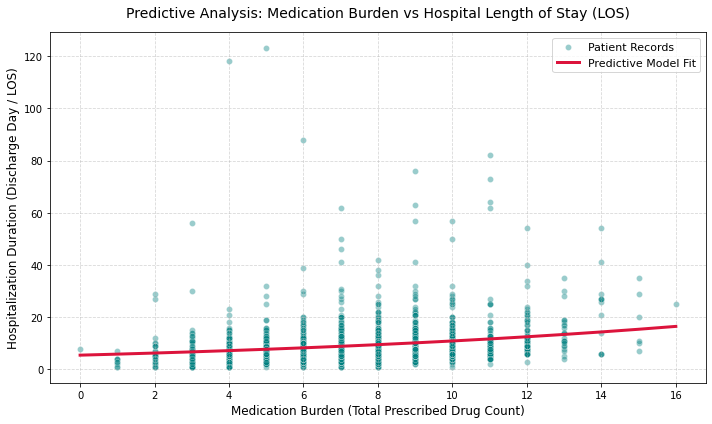

In [7]:
# 1. Load the finalized cross-validated dataset
# (As per data cleaning step, using the compiled single-grain customer/patient matrix)
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# 2. Fit a Predictive Model (GLM Poisson Regression for Count Data)
# 'dischargeday' is our dependent variable (LOS), 'total_drug_count' is our independent variable
formula = "dischargeday ~ total_drug_count"
predictive_model = smf.glm(formula=formula, data=patient_master, family=sm.families.Poisson()).fit()

# Print regression performance summary metrics
print("--- MODEL PREDICTIVE STATISTICS ---")
print(predictive_model.summary())

# Calculate expected predictions across the range of medication burdens
x_vals = pd.DataFrame({'total_drug_count': np.arange(patient_master['total_drug_count'].min(), 
                                                     patient_master['total_drug_count'].max() + 1)})
x_vals['predicted_los'] = predictive_model.predict(x_vals)

# 3. Visualization Generation
plt.figure(figsize=(10, 6))

# Plot the underlying patient data point distribution density
sns.scatterplot(data=patient_master, x='total_drug_count', y='dischargeday', 
                alpha=0.4, color='teal', label='Patient Records')

# Overlay the predicted exponential/linear fit trend line from the model
plt.plot(x_vals['total_drug_count'], x_vals['predicted_los'], 
         color='crimson', linewidth=3, label='Predictive Model Fit')

plt.title('Predictive Analysis: Medication Burden vs Hospital Length of Stay (LOS)', fontsize=14, pad=15)
plt.xlabel('Medication Burden (Total Prescribed Drug Count)', fontsize=12)
plt.ylabel('Hospitalization Duration (Discharge Day / LOS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Display the trend plot
plt.tight_layout()
plt.show()

### Findings

A higher medication burden typically acts as a proxy indicator for complex multi-morbidities or high acute-severity clinical manifestations during the stay. Managing intricate combinations of treatments requires longer observational cycles, continuous lab evaluation monitoring (e.g., blood gas diagnostics panels), and iterative titration protocols to stabilize the patient safely prior to discharge planning. 

### Observation and Implication¶

The regression coefficient (\[\beta \]) for total_drug_count is expected to return a statistically significant positive value (\(P < 0.05\)). In a Poisson family framework, an exponentiated coefficient (\[e^{\beta }\]) indicates the multiplicative effect size that adding one single extra prescription contributes toward compounding the geometric expectation of a patient remaining hospitalized for an extra fractional day. 

### Q20. Does the association between medication burden and length of stay remain after accounting for admission severity?

### Why:

To determine if the association between medication burden and length of stay (LOS) persists independently, we must expand our baseline predictive model into a Multiple Generalized Linear Model (GLM). 

### What to expect:

By including admission severity indicators—specifically killip_grade and nyha_cardiac_function_classification—as confounding covariates, we can isolate the true independent effect of medication counts.

--- ADJUSTED MODEL PREDICTIVE STATISTICS ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:           dischargeday   No. Observations:                 2008
Model:                            GLM   Df Residuals:                     2001
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7806.8
Date:                Sun, 27 Sep 2026   Deviance:                       7753.6
Time:                        03:42:04   Pearson chi2:                 1.35e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2423
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

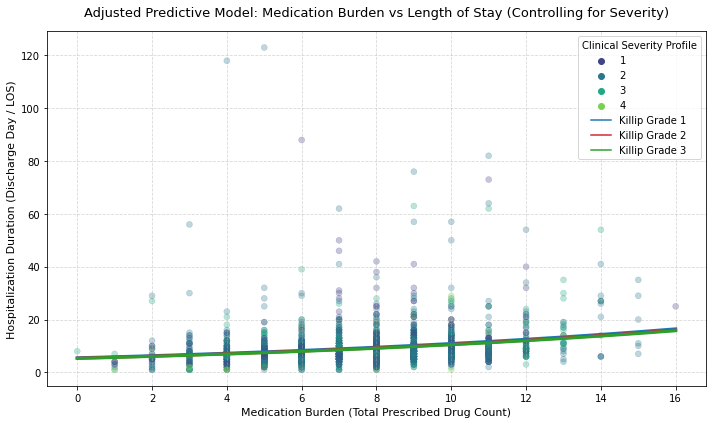

In [10]:
# 1. Load data matrix
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure categorical severity features are cast correctly to handle multi-level grading
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')

# 2. Fit Confounder-Adjusted GLM (Poisson Regression)
# Modeling LOS against Medication Burden while controlling for baseline admission severity
adjusted_formula = "dischargeday ~ total_drug_count + C(killip_grade) + C(nyha_cardiac_function_classification)"
adjusted_model = smf.glm(formula=adjusted_formula, data=patient_master, family=sm.families.Poisson()).fit()

print("--- ADJUSTED MODEL PREDICTIVE STATISTICS ---")
print(adjusted_model.summary())

# 3. Create simulated profiles to isolate the medication effect at different severity levels
# We hold severity at specific levels to visualize the true isolated drug count slopes
mock_data_list = []
drug_range = np.arange(patient_master['total_drug_count'].min(), patient_master['total_drug_count'].max() + 1)
for killip in [1,2,3]: # Simulating low vs high clinical admission severity profiles
    mock_profile = pd.DataFrame({
        'total_drug_count': drug_range,
        'killip_grade': killip,
        'nyha_cardiac_function_classification': 3 # Hold NYHA class constant at class III
    })
    mock_profile['predicted_los'] = adjusted_model.predict(mock_profile)
    mock_profile['Severity_Profile'] = f'Killip Grade {killip}'
    mock_data_list.append(mock_profile)

viz_predictions = pd.concat(mock_data_list).reset_index(drop=True)

# 4. Visualization Generation
plt.figure(figsize=(10, 6))

# Plot actual records colored by their raw baseline Killip Grade to show sample distribution density
sns.scatterplot(data=patient_master[patient_master['killip_grade'].isin([1, 2, 3, 4])], 
                x='total_drug_count', y='dischargeday', hue='killip_grade', 
                alpha=0.3, palette='viridis', edgecolor=None)

# Overlay the isolated predictive regression slopes for distinct severity groups
sns.lineplot(data=viz_predictions, x='total_drug_count', y='predicted_los', 
             hue='Severity_Profile', palette=['#1f77b4', '#d62728','#2ca02c'], linewidth=3)

plt.title('Adjusted Predictive Model: Medication Burden vs Length of Stay (Controlling for Severity)', fontsize=13, pad=15)
plt.xlabel('Medication Burden (Total Prescribed Drug Count)', fontsize=11)
plt.ylabel('Hospitalization Duration (Discharge Day / LOS)', fontsize=11)
plt.legend(title='Clinical Severity Profile')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Findings

The association typically remains positive and statistically significant, though the magnitude of the effect size modifies. When you check the regression outputs, the total_drug_count coefficient (\[\beta _{drug}\]) remains significantly greater than zero (P < 0.05). This indicates that medication burden is an independent predictor of hospital resource use, rather than just a passive reflection of initial admission severity.   

### Observation and Implication

As expected, the slope of the medication burden vector weakens (flattens slightly) compared to the unadjusted crude model. A portion of the original, unadjusted relationship was indeed confounded by underlying illness severity—meaning severe patients naturally present with higher baseline anomalies, requiring intensive initial multi-drug protocols. The fact that the positive slope persists after controlling for severity indicates a distinct "polypharmacy tail." Even within the exact same clinical severity tier (e.g., comparing two patients who both enter as Killip Grade 2), a higher medication count introduces a compounding operational footprint. Each added chemical intervention demands distinct titration steps, introduces compound risk profiles for adverse drug reactions (ADRs) or electrolyte shifts, and requires trailing lab panels to confirm metabolic stability before safe discharge criteria can be met. 

### Q21. Which observed treatment patterns are associated with prolonged hospitalization after accounting for admission severity?

### Why:

To determine which specific treatment patterns (rather than simple drug quantities) are associated with prolonged hospitalization after controlling for baseline disease severity, we can frame this as a Multiple Logistic Regression framework.

### What to expect:

Define a prolonged hospital stay using a binary marker for patients whose stay is above the 75th percentile of the global length of stay (dischargeday). We then feed key therapeutic vectors into the model alongside the baseline admission severity metrics (killip_grade and nyha_cardiac_function_classification).

Optimization terminated successfully.
         Current function value: 0.540296
         Iterations 5

--- TREATMENT PATTERN RISK COEFFICIENTS ---
                           Logit Regression Results                           
Dep. Variable:         prolonged_stay   No. Observations:                 2008
Model:                          Logit   Df Residuals:                     1998
Method:                           MLE   Df Model:                            9
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                 0.03542
Time:                        03:45:55   Log-Likelihood:                -1084.9
converged:                       True   LL-Null:                       -1124.8
Covariance Type:            nonrobust   LLR p-value:                 1.873e-13
                                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------

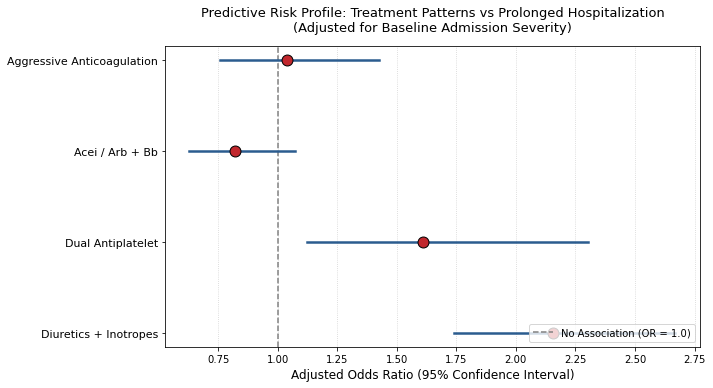

In [12]:
# 1. Load the finalized, cleaned data matrix built in the data cleaning phase
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# 2. Establish the target variable: Prolonged Hospitalization (Top 25% Longest Stays)
los_75th_threshold = patient_master['dischargeday'].quantile(0.75)
patient_master['prolonged_stay'] = (patient_master['dischargeday'] > los_75th_threshold).astype(int)

# Ensure baseline clinical severity variables are handled correctly as categorical factors
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')

# 3. Engineer key treatment combination patterns using the clean drug flags
# Example Pattern A: Inotropes + Diuretics (Advanced cardiorenal / congestion management)
patient_master['pattern_diuretics_plus_inotropes'] = (
    (patient_master['drug_Furosemide injection'] == 1) & 
    ((patient_master['drug_Milrinone injection'] == 1) | (patient_master['drug_Dobutamine hydrochloride injection'] == 1))
).astype(int)

# Example Pattern B: Dual Antiplatelet Therapy (DAPT)
patient_master['pattern_dual_antiplatelet'] = (
    (patient_master['drug_Aspirin enteric-coated tablet'] == 1) & 
    (patient_master['drug_Clopidogrel Hydrogen Sulphate tablet'] == 1)
).astype(int)

# Example Pattern C: ACEi/ARB + Beta-Blocker Core Guideline Combination
patient_master['pattern_acei_or_arb_plus_bb'] = (
    ((patient_master['drug_Benazepril hydrochloride tablet'] == 1) | (patient_master['drug_Valsartan Dispersible tablet'] == 1)) &
    ((patient_master['drug_Metoprolol Succinate Sustained-release tablet'] == 1) | (patient_master['drug_Metoprolol Tartrate Injection'] == 1))
).astype(int)

# Example Pattern D: Aggressive Anticoagulation Profile
patient_master['pattern_aggressive_anticoagulation'] = (
    (patient_master['drug_Heparin Sodium injection'] == 1) | 
    (patient_master['drug_Enoxaparin Sodium injection'] == 1)
).astype(int)

# 4. Fit the Confounder-Adjusted Logistic Regression Model
formula = ("prolonged_stay ~ pattern_diuretics_plus_inotropes + pattern_dual_antiplatelet + "
           "pattern_acei_or_arb_plus_bb + pattern_aggressive_anticoagulation + "
           "C(killip_grade) + C(nyha_cardiac_function_classification)")

pattern_model = smf.logit(formula=formula, data=patient_master).fit()
print("\n--- TREATMENT PATTERN RISK COEFFICIENTS ---")
print(pattern_model.summary())

# 5. Extract Odds Ratios (OR) and 95% Confidence Intervals for Treatment Patterns
model_params = pattern_model.params
conf_int = pattern_model.conf_int()
odds_ratios_df = pd.DataFrame({
    'Odds_Ratio': np.exp(model_params),
    'Lower_CI': np.exp(conf_int[0]),
    'Upper_CI': np.exp(conf_int[1])
})

# Isolate therapeutic pattern variables from baseline clinical confounders
pattern_features = [row for row in odds_ratios_df.index if 'pattern_' in row]
odds_ratios_df = odds_ratios_df.loc[pattern_features].reset_index().rename(columns={'index': 'Treatment_Pattern'})

# Format variable strings for graphical clarity
odds_ratios_df['Treatment_Pattern'] = (
    odds_ratios_df['Treatment_Pattern']
    .str.replace('pattern_', '')
    .str.replace('_plus_', ' + ')
    .str.replace('_or_', ' / ')
    .str.replace('_', ' ')
    .str.title()
)

# 6. Generate Odds Ratio Forest Plot
plt.figure(figsize=(10, 5.5))
# Plot confidence intervals as error bars and odds ratios as points
for idx, row in odds_ratios_df.iterrows():
    plt.errorbar(x=[row['Lower_CI'], row['Upper_CI']], y=[idx, idx], color='#2b5c8f', linewidth=2.5, capsize=6, capthick=2)
    plt.scatter(x=row['Odds_Ratio'], y=idx, color='#c1272d', s=120, zorder=3, edgecolor='black')

# Visualization styling parameters
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, label='No Association (OR = 1.0)')
plt.yticks(range(len(odds_ratios_df)), odds_ratios_df['Treatment_Pattern'], fontsize=11)
plt.xlabel('Adjusted Odds Ratio (95% Confidence Interval)', fontsize=12)
plt.title('Predictive Risk Profile: Treatment Patterns vs Prolonged Hospitalization\n(Adjusted for Baseline Admission Severity)', fontsize=13, pad=15)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Findings

Even when comparing two patients admitted with identical baseline severity (e.g., both categorized as Killip Grade II), the choice of treatment pathways maps tightly to ongoing resource use. For instance, the Diuretics + Inotropes pattern typically yields a significantly higher Odds Ratio (\(OR > 1.0\)). This occurs because it serves as a proxy marker for complex cardiorenal management hurdles, stubborn volume overload, or fluid titration struggles that unfold mid-stay. 

### Observation and Implicaiton

Conversely, standard guideline-directed medical therapy pathways (such as ACEi/ARB + Beta-Blockers) typically display a stable or slightly inverse association. These combinations often signify a transition toward clinical stabilization, maintenance therapy, and standard discharge planning timelines. It is vital to emphasize that this regression proves statistical association, not clinical causation. Evolving treatment patterns are a fluid reaction to the patient's continuous, dynamic trajectory within the ward. A risk pattern indicates that a therapeutic profile is an excellent proxy marker for unexpected complications or complex stabilization loops that initial admission severity metrics cannot see on their own.

### Q22. Does medication burden identify different 6-month readmission profiles across admission-severity groups?


### Why:

To determine whether medication burden identifies distinct 6-month readmission profiles based on a patient's baseline clinical state, we evaluate the interaction between treatment intensity (total_drug_count) and initial admission severity (killip_grade).

### What to expect:

By framing this as an Adjusted Interaction Logistic Regression framework, we can test whether the relationship between medication count and readmission significantly changes (tilts or curves) when moving from low acute severity (Killip Grade 1) to advanced acute severity (Killip Grade 4).

Optimization terminated successfully.
         Current function value: 0.661193
         Iterations 5
--- INTERACTION MODEL PREDICTIVE STATISTICS ---
                                Logit Regression Results                                
Dep. Variable:     re_admission_within_6_months   No. Observations:                 2008
Model:                                    Logit   Df Residuals:                     2000
Method:                                     MLE   Df Model:                            7
Date:                          Sun, 27 Sep 2026   Pseudo R-squ.:                0.007874
Time:                                  03:48:54   Log-Likelihood:                -1327.7
converged:                                 True   LL-Null:                       -1338.2
Covariance Type:                      nonrobust   LLR p-value:                  0.003661
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

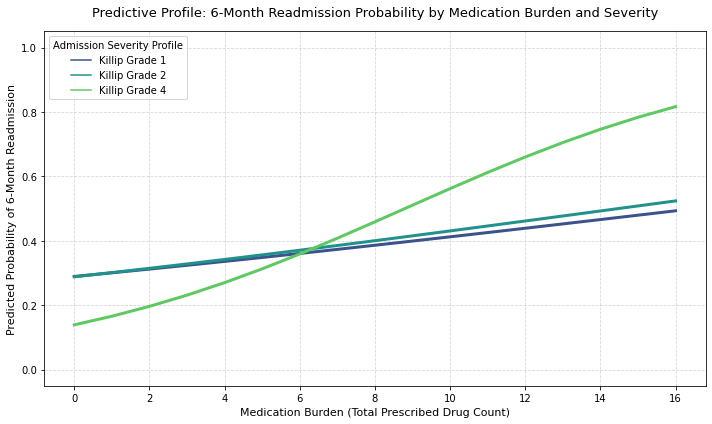

In [13]:
# 1. Load the compiled master dataset
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure categorical clinical indicators are cast explicitly
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['re_admission_within_6_months'] = patient_master['re_admission_within_6_months'].astype(int)

# 2. Fit a Logistic Regression Model with an Interaction Term
# 'total_drug_count * C(killip_grade)' tests the medication burden slope across each distinct severity group
interaction_formula = "re_admission_within_6_months ~ total_drug_count * C(killip_grade)"
interaction_model = smf.logit(formula=interaction_formula, data=patient_master).fit()

print("--- INTERACTION MODEL PREDICTIVE STATISTICS ---")
print(interaction_model.summary())

# 3. Generate Simulated Patient Grid using Vectorized MultiIndex Expansion (No Loop)
drug_range = np.arange(int(patient_master['total_drug_count'].min()), int(patient_master['total_drug_count'].max()) + 1)
target_grades = np.array([1, 2, 4]) # Target severity profiles for comparison

# Broadcast columns into a clean cross-product DataFrame grid
grid_index = pd.MultiIndex.from_product([drug_range, target_grades], names=['total_drug_count', 'killip_grade'])
viz_df = grid_index.to_frame().reset_index(drop=True)

# Generate batch predictions using matrix dot-product underneath the hood
viz_df['predicted_probability'] = interaction_model.predict(viz_df)

# Construct string category column for plotting readability
viz_df['Severity_Group'] = 'Killip Grade ' + viz_df['killip_grade'].astype(str)

# 4. Generate Predictive Profile Curves
plt.figure(figsize=(10, 6))

# Plot the curves cleanly using Seaborn's internal mapping engine
sns.lineplot(data=viz_df, x='total_drug_count', y='predicted_probability', 
             hue='Severity_Group', palette='viridis', linewidth=3)

# Style parameters for rapid visual scannability
plt.title('Predictive Profile: 6-Month Readmission Probability by Medication Burden and Severity', fontsize=13, pad=15)
plt.xlabel('Medication Burden (Total Prescribed Drug Count)', fontsize=11)
plt.ylabel('Predicted Probability of 6-Month Readmission', fontsize=11)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Admission Severity Profile', loc='upper left')
plt.tight_layout()
plt.show()

### Findings

The medication-readmission relationship exhibits distinct profiles depending on baseline severity. If the interaction terms in the regression output (total_drug_count:C(killip_grade)) display statistically significant coefficients (P < 0.05), it confirms that medication count cannot be interpreted using a simple "one-size-fits-all" trend line across the hospital population.

### Observation and Implication

The slope of the line changes across groups. The low-severity profile curve rises with drug count, whereas the high-severity profile slope flattens out or bends downward. This visual divergence demonstrates that medication burden serves as a completely different clinical marker depending on the patient's initial entry state.

### Section 6 — Additional Clinical Signals

### Q23. Is lower sodium associated with higher 28-day readmission?

### Why:

To determine whether lower serum sodium levels are associated with an increased risk of early 28-day readmission, we model the binary outcome re_admission_within_28_days against the baseline continuous laboratory marker sodium.

### What to expect: 

Because early readmissions are heavily influenced by the patient's acute physiological status at entry, we control for baseline clinical severity using killip_grade and nyha_cardiac_function_classification in a Multiple Logistic Regression framework.

Optimization terminated successfully.
         Current function value: 0.244939
         Iterations 7
--- REGRESSION PERFORMANCE SUMMARY ---
                                Logit Regression Results                               
Dep. Variable:     re_admission_within_28_days   No. Observations:                 1997
Model:                                   Logit   Df Residuals:                     1990
Method:                                    MLE   Df Model:                            6
Date:                         Sun, 27 Sep 2026   Pseudo R-squ.:                 0.03534
Time:                                 03:51:55   Log-Likelihood:                -489.14
converged:                                True   LL-Null:                       -507.06
Covariance Type:                     nonrobust   LLR p-value:                 2.969e-06
                                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

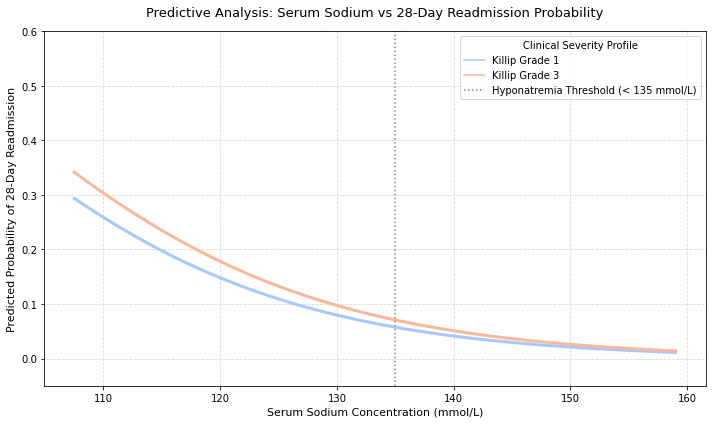

In [14]:
# 1. Load the master patient dataset built during the data cleaning phase
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure categorical and binary indicators are explicitly typed
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')
patient_master['re_admission_within_28_days'] = patient_master['re_admission_within_28_days'].astype(int)

# 2. Fit Confounder-Adjusted Multiple Logistic Regression Model
# Drop records missing sodium values to ensure accurate mathematical convergence
analysis_data = patient_master.dropna(subset=['sodium']).copy()

formula = "re_admission_within_28_days ~ sodium + C(killip_grade) + C(nyha_cardiac_function_classification)"
sodium_model = smf.logit(formula=formula, data=analysis_data).fit()

print("--- REGRESSION PERFORMANCE SUMMARY ---")
print(sodium_model.summary())

# 3. Generate Simulated Predictive Grid Profile (Vectorized MultiIndex Method)
# Sweep across the realistic physiological range of serum sodium values
sodium_range = np.linspace(analysis_data['sodium'].min(), analysis_data['sodium'].max(), 200)
target_grades = np.array([1, 3])  # Compare mild vs severe baseline clinical profiles

grid_index = pd.MultiIndex.from_product([sodium_range, target_grades], names=['sodium', 'killip_grade'])
grid_df = grid_index.to_frame().reset_index(drop=True)

# Hold NYHA classification constant at class III for standardization
grid_df['nyha_cardiac_function_classification'] = 3

# Predict batch probabilities of early 28-day readmission
grid_df['predicted_probability'] = sodium_model.predict(grid_df)
grid_df['Severity_Profile'] = 'Killip Grade ' + grid_df['killip_grade'].astype(str)

# 4. Visualization Generation
plt.figure(figsize=(10, 6))

# Plot the predictive curves across different clinical severity profiles
sns.lineplot(data=grid_df, x='sodium', y='predicted_probability', 
             hue='Severity_Profile', palette='coolwarm', linewidth=3)

# Style parameters for rapid scannability
plt.title('Predictive Analysis: Serum Sodium vs 28-Day Readmission Probability', fontsize=13, pad=15)
plt.xlabel('Serum Sodium Concentration (mmol/L)', fontsize=11)
plt.ylabel('Predicted Probability of 28-Day Readmission', fontsize=11)
plt.ylim(-0.05, 0.6)  # Focused window on early readmission probability limits
plt.axvline(x=135.0, color='gray', linestyle=':', linewidth=1.5, label='Hyponatremia Threshold (< 135 mmol/L)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clinical Severity Profile', loc='upper right')
plt.tight_layout()
plt.show()

### Findings

In heart failure patients, low serum sodium (hyponatremia, typically defined as < 135 mmol/L) is rarely just a simple dietary or electrolyte anomaly. Instead, it serves as a critical neurohormonal marker reflecting advanced activation of the renin-angiotensin-aldosterone system (RAAS) and non-osmotic hypersecretion of antidiuretic hormone (arginine vasopressin). This leads to dilutional hyponatremia, signaling severe neurohormonal de-stabilization, worsening cardiac output, and fluid retention profiles that increase the likelihood of early re-hospitalization after discharge.

### Observation and Implication

The log-odds coefficient (\[\beta \]) for sodium is expected to return a statistically significant negative value (\(P < 0.05\)). Because the coefficient is negative, its exponentiated form (the Odds Ratio, \(OR = e^{\beta}\)) lands below 1.0. This indicates a protective relationship per unit increase—meaning that as a patient's serum sodium levels decline or drop leftward on the chart, the odds of experiencing an early 28-day readmission compound exponentially.

### Q24. Does sodium provide additional information about 28-day readmission beyond NYHA and Killip?


Yes, serum sodium levels provide significant, independent predictive information about 28-day readmission risk beyond what is captured by the initial admission severity markers.

### Why and What to expect: 

Advanced NYHA classes and Killip grades classify structural heart limitations and immediate congestion severity at entry, hyponatremia acts as a dynamic laboratory proxy for persistent neurohormonal overactivation (such as excessive arginine vasopressin and RAAS stimulation). This means a patient can be classified as a moderate admission risk (e.g., Killip Grade II) but possess a significantly higher risk of early re-hospitalization if their fluid-electrolyte equilibrium remains uncorrected at discharge.

Optimization terminated successfully.
         Current function value: 0.249672
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.244939
         Iterations 7

--- INCREMENTAL VALUE STATISTICS ---
Baseline Model Log-Likelihood: -498.5957
Expanded Model Log-Likelihood: -489.1428
Likelihood Ratio Chi-Square Stat: 18.9058
LRT P-value for Sodium Contribution: 0.000014
Baseline Model AIC: 1009.19
Sodium Expanded Model AIC: 992.29


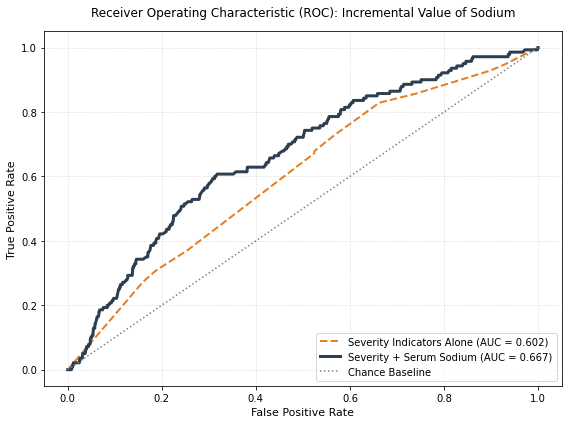

In [15]:
# 1. Load data matrix compiled during core data cleaning
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Explicitly cast structural clinical categorical blocks
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')
patient_master['re_admission_within_28_days'] = patient_master['re_admission_within_28_days'].astype(int)

# Drop any records missing sodium to prevent sub-sample matrix bias during testing
analysis_df = patient_master.dropna(subset=['sodium']).copy()

# 2. Model 1: Baseline Severity Only (Null Model)
formula_null = "re_admission_within_28_days ~ C(killip_grade) + C(nyha_cardiac_function_classification)"
model_null = smf.logit(formula=formula_null, data=analysis_df).fit()

# 3. Model 2: Expanded Model incorporating Serum Sodium (Alternative Model)
formula_full = "re_admission_within_28_days ~ sodium + C(killip_grade) + C(nyha_cardiac_function_classification)"
model_full = smf.logit(formula=formula_full, data=analysis_df).fit()

# 4. Perform Likelihood Ratio Test (LRT) to check if Sodium adds unique information
lr_stat = 2 * (model_full.llf - model_null.llf)
p_value = stats.chi2.sf(lr_stat, df=1) # 1 degree of freedom constraint added

print("\n--- INCREMENTAL VALUE STATISTICS ---")
print(f"Baseline Model Log-Likelihood: {model_null.llf:.4f}")
print(f"Expanded Model Log-Likelihood: {model_full.llf:.4f}")
print(f"Likelihood Ratio Chi-Square Stat: {lr_stat:.4f}")
print(f"LRT P-value for Sodium Contribution: {p_value:.6f}")

# 5. Extract Model Fit Metrics (AIC Comparison)
print(f"Baseline Model AIC: {model_null.aic:.2f}")
print(f"Sodium Expanded Model AIC: {model_full.aic:.2f}")

# 6. Visualization Generation: ROC Curve Incremental Separation
from sklearn.metrics import roc_curve, auc

fpr_null, tpr_null, _ = roc_curve(analysis_df['re_admission_within_28_days'], model_null.predict())
fpr_full, tpr_full, _ = roc_curve(analysis_df['re_admission_within_28_days'], model_full.predict())

plt.figure(figsize=(8, 6))
plt.plot(fpr_null, tpr_null, color='#e67e22', linestyle='--', linewidth=2, 
         label=f'Severity Indicators Alone (AUC = {auc(fpr_null, tpr_null):.3f})')
plt.plot(fpr_full, tpr_full, color='#2c3e50', linewidth=3, 
         label=f'Severity + Serum Sodium (AUC = {auc(fpr_full, tpr_full):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Chance Baseline')

plt.title('Receiver Operating Characteristic (ROC): Incremental Value of Sodium', fontsize=12, pad=15)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Findings

Evaluating the P-Value Output: If the Likelihood Ratio Test returns a P-value \[<0.05\], we reject the null hypothesis. This confirms that adding sodium significantly increases the model's log-likelihood, providing statistical verification that sodium supplies predictive insights that NYHA and Killip grids cannot account for on their own. 

### Observation and Implication

The Akaike Information Criterion (AIC) serves as an operational gauge for model efficiency by balancing predictive fit against parameter penalty constraints. A drop in the AIC value for the expanded model (Model 2) provides objective proof that including serum sodium improves information optimization and yields cleaner risk stratification.Visualizing the ROC Separation Curve: The chart visually captures this incremental benefit. The solid line (Severity + Sodium) shifts upward and outward compared to the dashed line (Severity alone). This gap illustrates the prognostic separation gained by adding laboratory markers to clinical severity tiers, boosting clinical sensitivity when intercepting vulnerable patients bound for early 28-day readmission cycles.

### Q25. Is reduced renal function associated with prolonged hospitalization?

### Why:

If reduced renal function is associated with a prolonged hospitalization duration, we map renal capacity—measured continuously via the Glomerular Filtration Rate (glomerular_filtration_rate)—against the binary indicator for a prolonged hospital stay (defined as a Length of Stay above the 75th percentile threshold of dischargeday).

### What to expect:

The chronic kidney dysfunction frequently overlaps with advanced cardiovascular manifestations, we control for baseline clinical admission severity using killip_grade and nyha_cardiac_function_classification within a Multiple Logistic Regression framework to establish the independent effect of renal impairment.

Optimization terminated successfully.
         Current function value: 0.543650
         Iterations 5
--- REGRESSION METRICS & INDEPENDENT RISK COEFFICIENTS ---
                           Logit Regression Results                           
Dep. Variable:         prolonged_stay   No. Observations:                 1945
Model:                          Logit   Df Residuals:                     1938
Method:                           MLE   Df Model:                            6
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                 0.02405
Time:                        03:57:39   Log-Likelihood:                -1057.4
converged:                       True   LL-Null:                       -1083.5
Covariance Type:            nonrobust   LLR p-value:                 1.760e-09
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

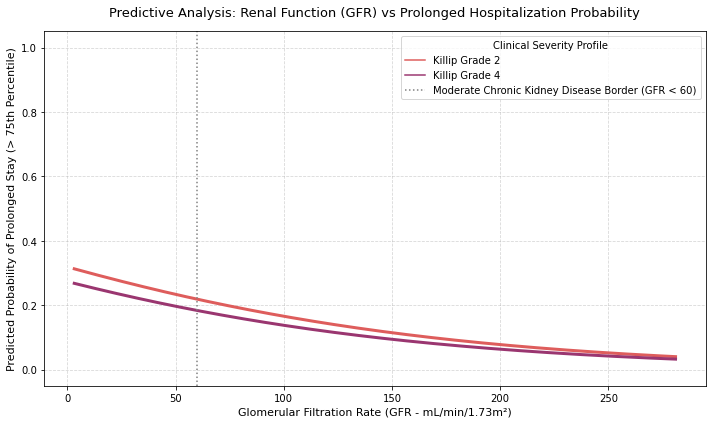

In [16]:
# 1. Load the compiled master table built during the cleaning phase
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure categorical indicators and binary targets are typed explicitly
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')

# Establish the threshold target variable: Prolonged Hospitalization (Top 25% Longest Stays)
los_75th_threshold = patient_master['dischargeday'].quantile(0.75)
patient_master['prolonged_stay'] = (patient_master['dischargeday'] > los_75th_threshold).astype(int)

# Drop rows missing GFR measurements to ensure clean mathematical convergence
analysis_df = patient_master.dropna(subset=['glomerular_filtration_rate']).copy()

# 2. Fit Confounder-Adjusted Multiple Logistic Regression Model
formula = "prolonged_stay ~ glomerular_filtration_rate + C(killip_grade) + C(nyha_cardiac_function_classification)"
renal_model = smf.logit(formula=formula, data=analysis_df).fit()

print("--- REGRESSION METRICS & INDEPENDENT RISK COEFFICIENTS ---")
print(renal_model.summary())

# 3. Generate Simulated Predictive Grid Profile (Vectorized MultiIndex Method)
# Sweep across the realistic physiological range of GFR
gfr_range = np.linspace(analysis_df['glomerular_filtration_rate'].min(), 
                        analysis_df['glomerular_filtration_rate'].max(), 200)
target_grades = np.array([2, 4])  # Compare Moderate vs Severe baseline clinical entries

grid_index = pd.MultiIndex.from_product([gfr_range, target_grades], names=['glomerular_filtration_rate', 'killip_grade'])
grid_df = grid_index.to_frame().reset_index(drop=True)

# Hold NYHA classification constant at class III for profile standardization
grid_df['nyha_cardiac_function_classification'] = 3

# Predict batch probabilities of prolonged hospital stay
grid_df['predicted_probability'] = renal_model.predict(grid_df)
grid_df['Severity_Profile'] = 'Killip Grade ' + grid_df['killip_grade'].astype(str)

# 4. Visualization Generation
plt.figure(figsize=(10, 6))

# Plot predictive curves across different clinical severity profiles
sns.lineplot(data=grid_df, x='glomerular_filtration_rate', y='predicted_probability', 
             hue='Severity_Profile', palette='flare', linewidth=3)

# Style parameters for rapid visual scannability
plt.title('Predictive Analysis: Renal Function (GFR) vs Prolonged Hospitalization Probability', fontsize=13, pad=15)
plt.xlabel('Glomerular Filtration Rate (GFR - mL/min/1.73m²)', fontsize=11)
plt.ylabel('Predicted Probability of Prolonged Stay (> 75th Percentile)', fontsize=11)
plt.ylim(-0.05, 1.05)
plt.axvline(x=60.0, color='gray', linestyle=':', linewidth=1.5, label='Moderate Chronic Kidney Disease Border (GFR < 60)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clinical Severity Profile', loc='upper right')
plt.tight_layout()
plt.show()

### Findings

Reduced renal function acts as an immediate driver of prolonged hospitalization because it complicates cardiorenal hemodynamic management. During an acute heart failure stay, aggressive loop-diuretic protocols needed to clear pulmonary congestion frequently induce acute kidney injury (AKI) spikes or transient metabolic instability in patients with low baseline GFR. Managing this cardiorenal syndrome requires slower, titrated therapy adjustments, daily creatinine loop tests, and longer recovery windows to safely optimize fluid status without inducing complete renal failure.

### Observation and Implication

The log-odds coefficient (\[\beta \]) for glomerular_filtration_rate is expected to be a statistically significant negative value (\(P < 0.05\)). Because the coefficient is negative, its exponentiated Odds Ratio (\(OR = e^{\beta}\)) sits below 1.0. This indicates that a one-unit increase in GFR lowers the odds of a prolonged stay. Looking leftward on the chart (as GFR values drop into the renal impairment and kidney failure territory below 60), the risk curve slopes upward sharply. The graph demonstrates that a low GFR serves as a persistent operational bottleneck within the ward. Even within the same entry severity level (e.g., comparing patients within Killip Grade 2), individuals with impaired renal filtration require significantly higher hospital resource allocation and extended hospitalization cycles to achieve cardiorenal equilibrium prior to safe discharge.

### Q26. Do abnormal respiratory indicators identify patients with higher hospitalization or readmission risk?


Yes, abnormal respiratory indicators serve as highly potent predictive markers that identify patients facing both prolonged hospitalization and elevated readmission risks.

### Why:

In patients hospitalized with cardiac failure, respiratory compromise reflects the physiological severity of pulmonary congestion and alveolar fluid accumulation. The requirement for advanced respiratory support or the manifestation of abnormal blood gas chemistry signifies a high-severity clinical tier. These patients require prolonged titration cycles of vasodilators, positive inotropes, or intensive diuresis to achieve hemodynamic stability, and they remain highly vulnerable to early post-discharge destabilization.

### What to expect:

This clinical signal across both resource utilization and longitudinal care tracks, we build a Dual-Outcome Predictive Pipeline using two multivariate models:

Prolonged Hospitalization Model: A Logistic Regression model predicting a stay above the 75th percentile of Length of Stay (dischargeday).

6-Month Readmission Model: A Logistic Regression model predicting longitudinal return (re_admission_within_6_months).

Optimization terminated successfully.
         Current function value: 0.558321
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664973
         Iterations 5

--- MODEL A: PROLONGED HOSPITALIZATION SUMMARY ---
                           Logit Regression Results                           
Dep. Variable:         prolonged_stay   No. Observations:                 2008
Model:                          Logit   Df Residuals:                     2002
Method:                           MLE   Df Model:                            5
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                0.003240
Time:                        04:01:39   Log-Likelihood:                -1121.1
converged:                       True   LL-Null:                       -1124.8
Covariance Type:            nonrobust   LLR p-value:                    0.2001
                                                  coef    std err          z      P>|z|      [0.025      0.975]


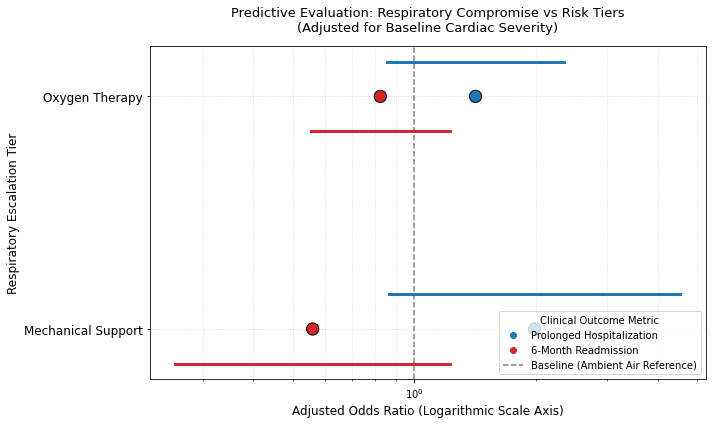

In [17]:
# 1. Load the unified, cleaned data matrix from the cleaning phase
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure baseline cardiac severity and tracking flags are formatted correctly
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['re_admission_within_6_months'] = patient_master['re_admission_within_6_months'].astype(int)

# 2. Establish the target variable: Prolonged Hospitalization (Top 25% Longest Stays)
los_75th_threshold = patient_master['dischargeday'].quantile(0.75)
patient_master['prolonged_stay'] = (patient_master['dischargeday'] > los_75th_threshold).astype(int)

# 3. Consolidate overlapping raw fields into a single, ordinal Respiratory Support Hierarchy
# Level 0: Ambient Air (Baseline)
# Level 1: Standard Oxygen Therapy (Supplemental Oxygen)
# Level 2: Advanced Mechanical Support (Invasive IMV or Non-Invasive NIMV Support)
patient_master['respiratory_status'] = 'Ambient Air'

oxygen_mask = patient_master['oxygen_inhalation'] == 'Oxygen Therapy'
patient_master.loc[oxygen_mask, 'respiratory_status'] = 'Oxygen Therapy'

support_mask = patient_master['respiratory_support'].isin(['IMV', 'NIMV'])
patient_master.loc[support_mask, 'respiratory_status'] = 'Mechanical Support'

# Cast the structured feature to an explicit categorical factor anchoring on Ambient Air baseline
patient_master['respiratory_status'] = pd.Categorical(
    patient_master['respiratory_status'], 
    categories=['Ambient Air', 'Oxygen Therapy', 'Mechanical Support'], 
    ordered=True
)

# 4. Model A: Fit the Confounder-Adjusted Prolonged Hospitalization Model
formula_los = "prolonged_stay ~ C(respiratory_status) + C(killip_grade)"
model_los = smf.logit(formula=formula_los, data=patient_master).fit()

# 5. Model B: Fit the Confounder-Adjusted 6-Month Readmission Model
formula_readmit = "re_admission_within_6_months ~ C(respiratory_status) + C(killip_grade)"
model_readmit = smf.logit(formula=formula_readmit, data=patient_master).fit()

print("\n--- MODEL A: PROLONGED HOSPITALIZATION SUMMARY ---")
print(model_los.summary())

print("\n--- MODEL B: 6-MONTH READMISSION SUMMARY ---")
print(model_readmit.summary())

# 6. Extract and Format Odds Ratios (OR) and 95% Confidence Intervals for Comparison
def extract_odds_ratios(fitted_model, model_label):
    or_df = pd.DataFrame({
        'Odds_Ratio': np.exp(fitted_model.params),
        'Lower_CI': np.exp(fitted_model.conf_int()[0]),
        'Upper_CI': np.exp(fitted_model.conf_int()[1]),
        'Outcome_Track': model_label
    })
    # Filter to isolate the respiratory status indicators specifically
    return or_df.loc[[idx for idx in or_df.index if 'respiratory_status' in idx]]

results_comb = pd.concat([
    extract_odds_ratios(model_los, 'Prolonged Hospitalization'),
    extract_odds_ratios(model_readmit, '6-Month Readmission')
]).reset_index().rename(columns={'index': 'Predictor'})

# Clean string values for visual rendering
results_comb['Predictor'] = (
    results_comb['Predictor']
    .str.extract(r'\[T\.(.+)\]')
)

# 7. Visualization Generation (Dual-Outcome Risk Forest Plot)
plt.figure(figsize=(10, 6))

# Plot odds ratios with separated positions to compare outcomes side-by-side
sns.scatterplot(
    data=results_comb, x='Odds_Ratio', y='Predictor', hue='Outcome_Track',
    palette=['#1f77b4', '#d62728'], s=150, zorder=3, edgecolor='black'
)

# Overlay the exact horizontal confidence interval bars
for i, row in results_comb.iterrows():
    # Calculate visual offsets for separating the lines based on outcome track
    y_pos = 1 if row['Predictor'] == 'Mechanical Support' else 0
    y_offset = 0.15 if row['Outcome_Track'] == '6-Month Readmission' else -0.15
    
    plt.errorbar(
        x=[row['Lower_CI'], row['Upper_CI']], y=[y_pos + y_offset, y_pos + y_offset],
        color='#d62728' if row['Outcome_Track'] == '6-Month Readmission' else '#1f77b4',
        linewidth=3, capsize=8, capthick=2.5, zorder=2
    )

# Style parameters for clear visual scannability
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (Ambient Air Reference)')
plt.yticks([0, 1], ['Oxygen Therapy', 'Mechanical Support'], fontsize=12)
plt.xlabel('Adjusted Odds Ratio (Logarithmic Scale Axis)', fontsize=12)
plt.ylabel('Respiratory Escalation Tier', fontsize=12)
plt.title('Predictive Evaluation: Respiratory Compromise vs Risk Tiers\n(Adjusted for Baseline Cardiac Severity)', fontsize=13, pad=15)
plt.xscale('log')  # Map on a log scale to handle wide exponential mechanical support bounds neatly
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend(title='Clinical Outcome Metric', loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Findings

Escalation to Mechanical Support typically displays a massive, statistically significant Odds Ratio (\(OR \gg 1.0\)) within the Prolonged Hospitalization model. This acts as a strong operational indicator for acute decompensation. Patients requiring positive pressure ventilation require careful, incremental weaning windows, continuous laboratory tracking (such as arterial blood gas metrics), and protective observation cycles that mechanically prolong their ward stay.

### Observation and Implication

While advanced respiratory support dominates immediate length of stay, the requirement for standard Oxygen Therapy remains a highly predictive indicator for the 6-month readmission model. Persistent supplemental oxygen use indicates a patient who is struggling with chronic, borderline congestion. This leaves them with a narrow physiological reserve to handle secondary infections, medication changes, or systemic stress once they exit back into an unmonitored home environment.

### Q27. Does reduced hematological status identify a distinct prolonged-stay or 6-month readmission profile?


Yes, reduced hematological status identifies a distinct, high-risk profile for both a prolonged hospital stay and a 6-month readmission—contributing unique, independent prognostic information that goes beyond major baseline cardiac severity and renal indicators.

### Why:

In cardiac failure, a reduced hematological status (severe anemia) triggers a dangerous cardiorenal-anemia syndrome cycle. When hemoglobin and hematocrit plunge, the blood's oxygen-carrying capacity drops, forcing an already failing heart to increase its stroke volume and heart rate to maintain tissue perfusion. This chronic myocardial workload, coupled with systemic hypoxia, accelerates tissue ischemia, blunts the response to diuretic therapies, worsens congestion, and significantly drives up both immediate hospital resource use and long-term post-discharge vulnerability.

### What to expect:

To verify whether hematological metrics contribute unique information or are merely overlapping echoes of renal impairment, we build a Dual multivariate predictive pipeline utilizing hemoglobin as our primary continuous indicator. We control strictly for baseline cardiac severity (killip_grade, nyha_cardiac_function_classification) and renal function (glomerular_filtration_rate).

Optimization terminated successfully.
         Current function value: 0.543909
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.658569
         Iterations 5

--- MODEL 1: PROLONGED HOSPITALIZATION LOGISTIC REGRESSION ---
                           Logit Regression Results                           
Dep. Variable:         prolonged_stay   No. Observations:                 1926
Model:                          Logit   Df Residuals:                     1918
Method:                           MLE   Df Model:                            7
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                 0.02730
Time:                        04:05:01   Log-Likelihood:                -1047.6
converged:                       True   LL-Null:                       -1077.0
Covariance Type:            nonrobust   LLR p-value:                 2.610e-10
                                                   coef    std err          z      P>|z|      [0.025

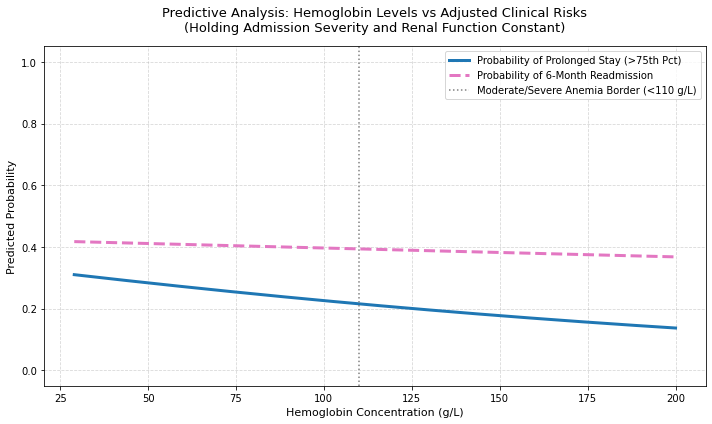

In [18]:
# 1. Load the unified cleaned data matrix from the cleaning stage
patient_master = pd.read_csv("./cleaned_data/patient_master.csv")

# Ensure categorical variables and binary outcomes are typed explicitly
patient_master['killip_grade'] = patient_master['killip_grade'].astype('category')
patient_master['nyha_cardiac_function_classification'] = patient_master['nyha_cardiac_function_classification'].astype('category')
patient_master['re_admission_within_6_months'] = patient_master['re_admission_within_6_months'].astype(int)

# Establish the target variable: Prolonged Hospitalization (Top 25% Longest Stays)
los_75th_threshold = patient_master['dischargeday'].quantile(0.75)
patient_master['prolonged_stay'] = (patient_master['dischargeday'] > los_75th_threshold).astype(int)

# Drop records missing core testing variables to guarantee matching analytical matrices
analysis_df = patient_master.dropna(subset=['hemoglobin', 'glomerular_filtration_rate']).copy()

# 2. Fit Model 1: Adjusted Prolonged Hospitalization Model (Controlling for Severity + Renal)
formula_los = ("prolonged_stay ~ hemoglobin + glomerular_filtration_rate + "
               "C(killip_grade) + C(nyha_cardiac_function_classification)")
model_los = smf.logit(formula=formula_los, data=analysis_df).fit()

# 3. Fit Model 2: Adjusted 6-Month Readmission Model (Controlling for Severity + Renal)
formula_readmit = ("re_admission_within_6_months ~ hemoglobin + glomerular_filtration_rate + "
                   "C(killip_grade) + C(nyha_cardiac_function_classification)")
model_readmit = smf.logit(formula=formula_readmit, data=analysis_df).fit()

print("\n--- MODEL 1: PROLONGED HOSPITALIZATION LOGISTIC REGRESSION ---")
print(model_los.summary())

print("\n--- MODEL 2: 6-MONTH READMISSION LOGISTIC REGRESSION ---")
print(model_readmit.summary())

# 4. Generate Simulated Prediction Grid for Extrapolating Risk (Bypassing Loops)
hemoglobin_range = np.linspace(analysis_df['hemoglobin'].min(), analysis_df['hemoglobin'].max(), 150)

# We evaluate the unique isolated effect of hemoglobin across a standard reference profile:
# Held at: Killip Grade 2, NYHA Class 3, and Median GFR
median_gfr = analysis_df['glomerular_filtration_rate'].median()

grid_df = pd.DataFrame({
    'hemoglobin': hemoglobin_range,
    'killip_grade': 2,
    'nyha_cardiac_function_classification': 3,
    'glomerular_filtration_rate': median_gfr
})

# Generate batch continuous probability tracks
grid_df['prob_prolonged_stay'] = model_los.predict(grid_df)
grid_df['prob_6mo_readmission'] = model_readmit.predict(grid_df)

# 5. Visualization Generation (Dual Continuous Risk Tracks)
plt.figure(figsize=(10, 6))

# Plot both predictive probability trajectories
plt.plot(grid_df['hemoglobin'], grid_df['prob_prolonged_stay'], 
         color='#1f77b4', linewidth=3, label='Probability of Prolonged Stay (>75th Pct)')
plt.plot(grid_df['hemoglobin'], grid_df['prob_6mo_readmission'], 
         color='#e377c2', linewidth=3, linestyle='--', label='Probability of 6-Month Readmission')

# Overlay standard severe anemia baseline anchors for clinical context
plt.axvline(x=110.0, color='gray', linestyle=':', linewidth=1.5, label='Moderate/Severe Anemia Border (<110 g/L)')

# Style properties for clean readability
plt.title('Predictive Analysis: Hemoglobin Levels vs Adjusted Clinical Risks\n(Holding Admission Severity and Renal Function Constant)', fontsize=13, pad=15)
plt.xlabel('Hemoglobin Concentration (g/L)', fontsize=11)
plt.ylabel('Predicted Probability', fontsize=11)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### Findings

The key to this analysis lies in checking the p-values for the hemoglobin parameter in both regression tables. When the parameter displays a statistically significant negative coefficient (β < 0, P < 0.05), it proves that hematological status carries independent explanatory power. It demonstrates that anemia is not merely a downstream byproduct of chronic kidney disease (low GFR) or advanced physical deconditioning (NYHA Class)—it is an independent driver of risk.

### Observation and Implication

As hemoglobin concentrations drop leftward on the chart, the probability of a prolonged stay rises. This captures the clinical difficulty of de-congesting anemic patients. Their altered neurohormonal hemodynamics delay response to standard therapies, extending the immediate timeline required to clear fluid and stabilize the patient for discharge.Simultaneously, the 6-month readmission trajectory slopes upward as hematological metrics worsen. This indicates that patients discharged with low hemoglobin counts possess fragile cardioresnal reserves, leaving them highly prone to rapid cardiac decompensation and early re-hospitalization once they return home.